<a href="https://colab.research.google.com/github/Adyan213/Hands-On-ML/blob/main/Chapter_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier

In [2]:
from numpy import random
iris=load_iris(as_frame=True)
X_iris=iris.data[["petal length (cm)", "petal width (cm)"]].values
y_iris=iris.target

tree_clf=DecisionTreeClassifier(max_depth=2, random_state=42)
tree_clf.fit(X_iris, y_iris)

DecisionTreeClassifier(max_depth=2, random_state=42)

In [3]:
from sklearn.tree import export_graphviz

export_graphviz(
    tree_clf,
    out_file="iris_tree.dot",
    feature_names=["petal length (cm)", "petal width (cm)"],
    class_names=iris.target_names,
    rounded=True,
    filled=True
)

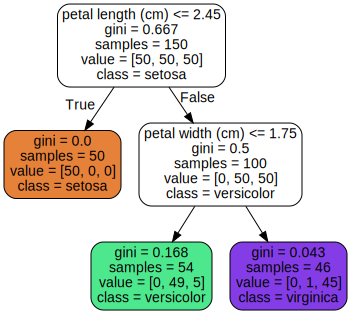

In [4]:
from graphviz import Source

Source.from_file("iris_tree.dot")

In [5]:
tree_clf.tree_

In [6]:
tree_clf.predict_proba([[5, 1.5]]).round(3)

array([[0.   , 0.907, 0.093]])

In [7]:
tree_clf.predict([[5, 1.5]])

array([1])

In [8]:
from sklearn.datasets import make_moons

X_moons, y_moons=make_moons(n_samples=150, noise=0.2, random_state=42)

tree_clf1=DecisionTreeClassifier(random_state=42)
tree_clf2=DecisionTreeClassifier(min_samples_leaf=5, random_state=42)

tree_clf1.fit(X_moons, y_moons)
tree_clf2.fit(X_moons, y_moons)

DecisionTreeClassifier(min_samples_leaf=5, random_state=42)

In [9]:
X_moons_test, y_moons_test=make_moons(n_samples=1000, noise=0.2, random_state=43)
tree_clf1.score(X_moons_test, y_moons_test)

0.898

In [10]:
tree_clf2.score(X_moons_test, y_moons_test)

0.92

In [11]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor

np.random.seed(42)
X_quad=np.random.rand(200, 1)-0.5
y_quad=X_quad**2+0.025*np.random.randn(200, 1)

tree_reg=DecisionTreeRegressor(max_depth=2, random_state=42)
tree_reg.fit(X_quad, y_quad)

DecisionTreeRegressor(max_depth=2, random_state=42)

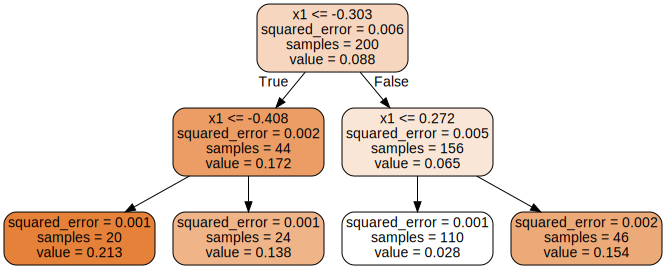

In [12]:
export_graphviz(
    tree_reg,
    out_file="quad_tree.dot",
    feature_names=["x1"],
    rounded=True,
    filled=True
)
Source.from_file("quad_tree.dot")

In [13]:
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

pca_pipeline=make_pipeline(StandardScaler(), PCA())
X_iris_rotated=pca_pipeline.fit_transform(X_iris)
tree_clf_pca=DecisionTreeClassifier(max_depth=2, random_state=42)
tree_clf_pca.fit(X_iris_rotated, y_iris)

DecisionTreeClassifier(max_depth=2, random_state=42)

In [14]:
tree=tree_clf.tree_
tree

In [15]:
tree.node_count

5

In [16]:
tree.max_depth

2

In [17]:
tree.max_n_classes

3

In [18]:
tree.n_features

2

In [19]:
tree.n_outputs

1

In [20]:
tree.n_leaves

np.int64(3)

In [21]:
tree.impurity

array([0.66666667, 0.        , 0.5       , 0.16803841, 0.04253308])

In [22]:
tree.children_left[0], tree.children_right[0]

(np.int64(1), np.int64(2))

In [23]:
is_leaf=(tree.children_left==tree.children_right)
np.arange(tree.node_count)[is_leaf]

array([1, 3, 4])

In [24]:
tree.feature

array([ 0, -2,  1, -2, -2], dtype=int64)

In [25]:
tree.threshold

array([ 2.44999999, -2.        ,  1.75      , -2.        , -2.        ])

In [26]:
tree.value

array([[[0.33333333, 0.33333333, 0.33333333]],

       [[1.        , 0.        , 0.        ]],

       [[0.        , 0.5       , 0.5       ]],

       [[0.        , 0.90740741, 0.09259259]],

       [[0.        , 0.02173913, 0.97826087]]])

In [27]:
tree.n_node_samples

array([150,  50, 100,  54,  46], dtype=int64)

In [28]:
np.all(tree.value.sum(axis=(1, 2)) == tree.n_node_samples)

np.False_

Exersice


In [29]:
from sklearn.datasets import make_moons
X_moons, y_moons=make_moons(n_samples=10000, noise=0.4, random_state=42)

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test=train_test_split(X_moons, y_moons, test_size=0.2, random_state=42)

In [31]:
from sklearn.model_selection import GridSearchCV

params={
    "max_leaf_nodes": list(range(2, 100)),
    "max_depth": list(range(1, 7)),
    "min_samples_split": [2, 3, 4],
}
grid_search_cv=GridSearchCV(DecisionTreeClassifier(random_state=42), params, cv=3)
grid_search_cv.fit(X_train, y_train)

GridSearchCV(cv=3, estimator=DecisionTreeClassifier(random_state=42),
             param_grid={'max_depth': [1, 2, 3, 4, 5, 6],
                         'max_leaf_nodes': [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12,
                                            13, 14, 15, 16, 17, 18, 19, 20, 21,
                                            22, 23, 24, 25, 26, 27, 28, 29, 30,
                                            31, ...],
                         'min_samples_split': [2, 3, 4]})

In [32]:
from sklearn.metrics import accuracy_score

y_pred=grid_search_cv.predict(X_test)
accuracy_score(y_test, y_pred)

0.8595

In [33]:
from sklearn.model_selection import ShuffleSplit

n_trees=1000
n_instances=100
mini_sets=[]
rs=ShuffleSplit(n_splits=n_trees, test_size=len(X_train)-n_instances, random_state=42)

for mini_train_index, mini_test_index in rs.split(X_train):
    X_mini_train=X_train[mini_train_index]
    y_mini_train=y_train[mini_train_index]
    mini_sets.append((X_mini_train, y_mini_train))

In [34]:
from sklearn.base import clone

forest=[clone(grid_search_cv.best_estimator_) for _ in range(n_trees)]

accuracy_scores=[]

for tree, (X_mini_train, y_mini_train) in zip(forest, mini_sets):
    tree.fit(X_mini_train, y_mini_train)
    y_pred=tree.predict(X_test)
    accuracy_scores.append(accuracy_score(y_test, y_pred))

np.mean(accuracy_scores)

np.float64(0.8056605)

In [36]:
Y_pred=np.empty([n_trees, len(X_test)], dtype=np.uint8)
for tree_index, tree in enumerate(forest):
    Y_pred[tree_index]=tree.predict(X_test)

In [37]:
from scipy.stats import mode

y_pred_majority_votes, n_votes=mode(Y_pred, axis=0)

In [38]:
accuracy_score(y_test, y_pred_majority_votes.reshape([-1]))

0.873